# Lattice Schwinger model simulation

This notebook uses a three-site, two-flavor Schwinger-model phase scan: `N = 3`, `F = 2`, `x = 16`, and a two-repetition charge-preserving ansatz. The flavor-0 chemical-potential scan uses `k = [K, 0]`, and exact references are restricted to the three-particle sector preserved by the ansatz.


In [1]:
import warnings
from math import pi
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import OptimizeWarning

import vqe_lab as vqe

ROOT = Path.cwd().resolve()
for _ in range(5):
    if (ROOT / "workloads").is_dir() and (ROOT / "pyproject.toml").is_file():
        break
    ROOT = ROOT.parent
else:
    raise RuntimeError("Could not find the project root.")

warnings.filterwarnings(
    "ignore",
    message="Unknown solver options: iprint",
    category=OptimizeWarning,
)


## Setup and exact reference
Before we start the investigation, we set up the model from the corresponding workload and calculate the exact energy and half-chain entropy.

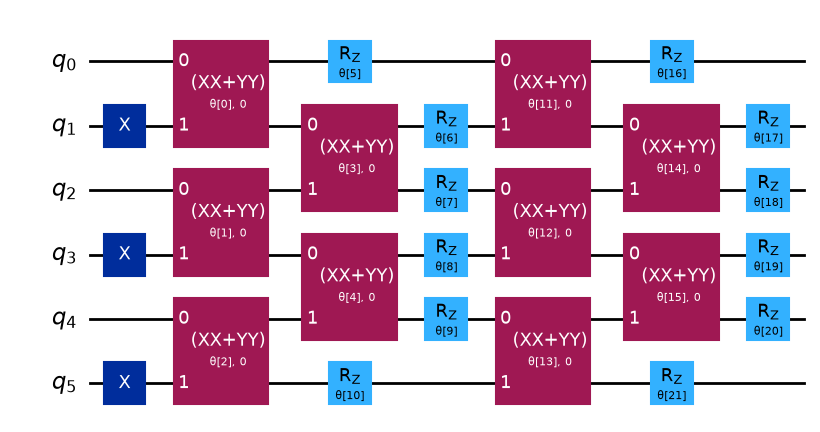

In [2]:
model = vqe.load_workload(ROOT / "workloads" / "schwinger.py")

N, F, X = 3, 2, 16.0
HAMILTONIAN = {"N": N, "F": F, "m": [0.0] * F, "x": X, "k": [0.0] * F}
ANSATZ = {"N": N, "F": F, "reps": 2}

vqe.draw_ansatz(model.ansatz(**ANSATZ), fold=30)

We create an experiment with a combination of Hamiltonian and ansatz.
Then, we determine the exact ground state by diagonalizing the matrix.

In [3]:
base = vqe.Experiment(model, hamiltonian=HAMILTONIAN, ansatz=ANSATZ)
exact = base.exact(return_eigenvector=True, particle_number=N * F // 2)
exact_entropy = vqe.entropy(exact.eigenvector)

print(f"Exact ground state energy: {exact.energy:.8f}")
print(f"Half-chain entanglement entropy: {exact_entropy:.8f} bits")

Exact ground state energy: -43.10950126
Half-chain entanglement entropy: 1.51137899 bits


## Gate angles across phases

The ansatz uses the smallest useful depth for this larger instance: two repetitions. The phase-aware starts deliberately do not use the known optimum. In every repetition, all five XY angles start at `0.25` for `K=-14`, `π/2` for `K=0`, or `π-0.25` for `K=10`; all RZ angles start at zero. A seeded Gaussian displacement (`0.10`) makes the convergence trajectories visible while retaining reliable convergence.

For `K=0`, the two-repetition ansatz reaches a small residual variational error (about `0.006`) relative to the three-particle-sector exact energy.


Exact ground state energy for K = -14: -334.50000000
Half-chain entanglement entropy for K = -14: -0.00000000 bits



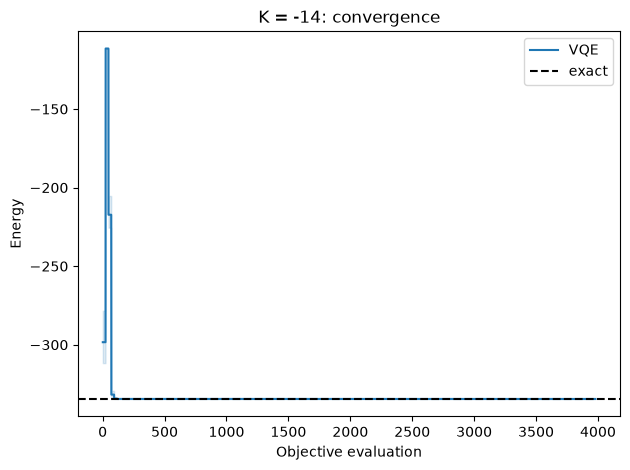

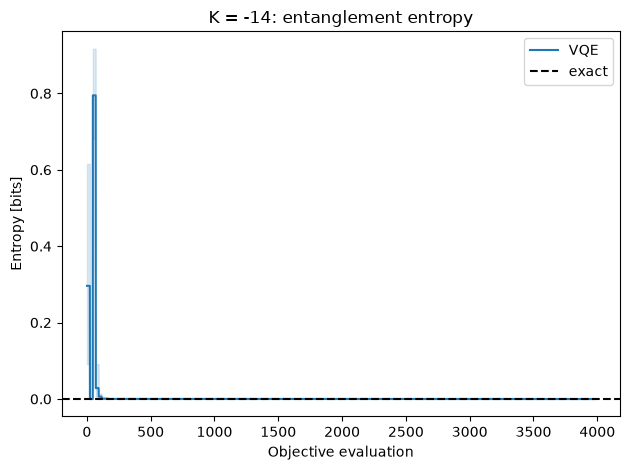

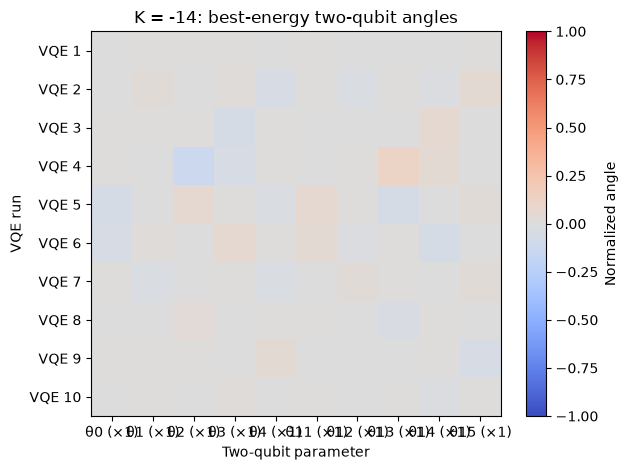

Exact ground state energy for K = 0: -43.10950126
Half-chain entanglement entropy for K = 0: 1.51137899 bits



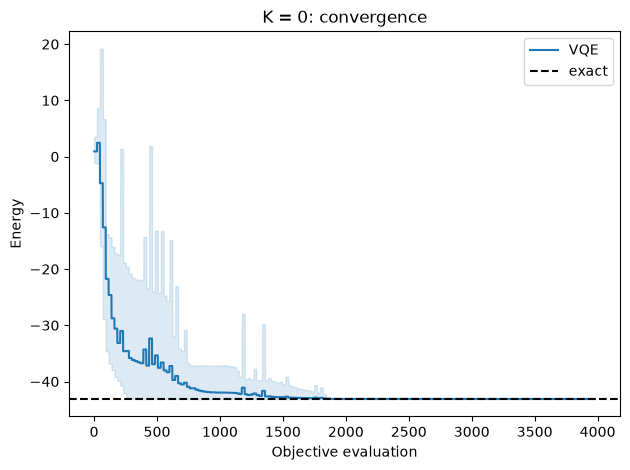

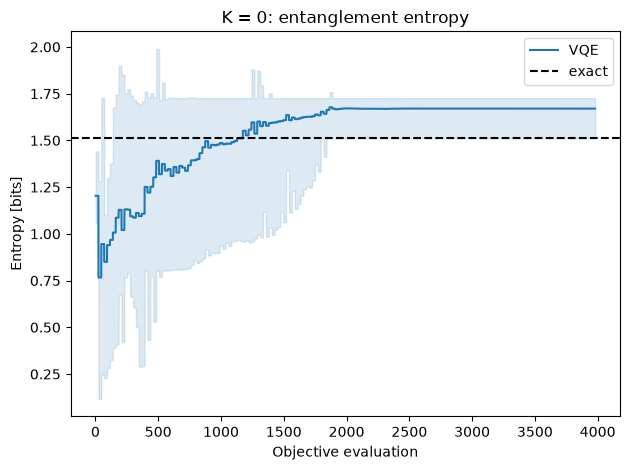

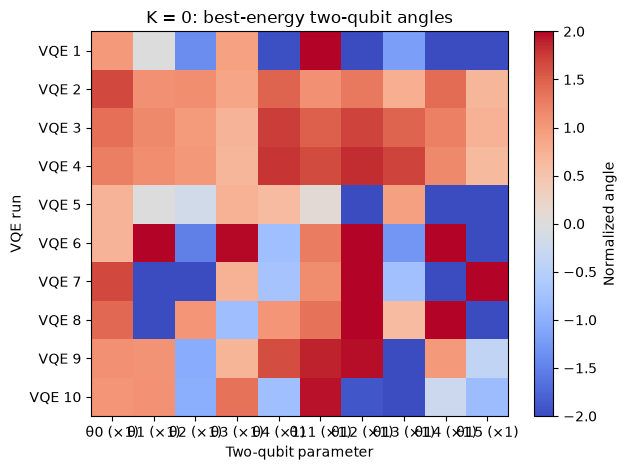

Exact ground state energy for K = 10: 1.50000000
Half-chain entanglement entropy for K = 10: 0.00000000 bits



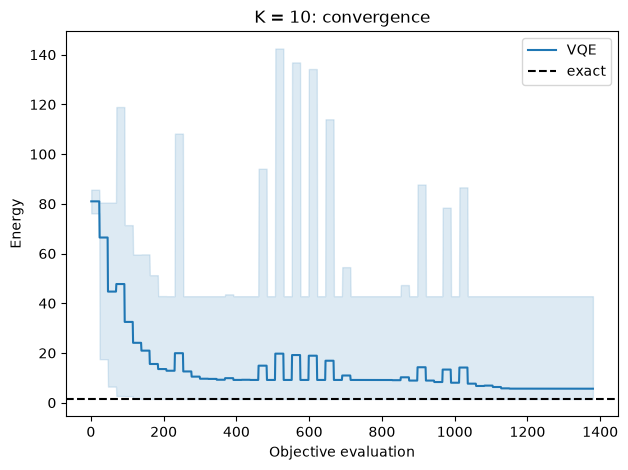

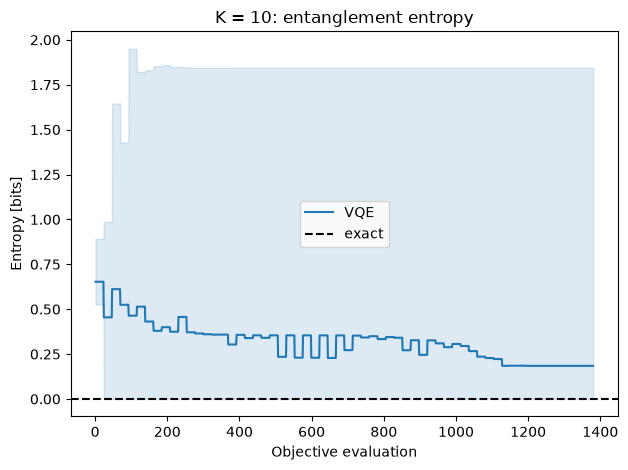

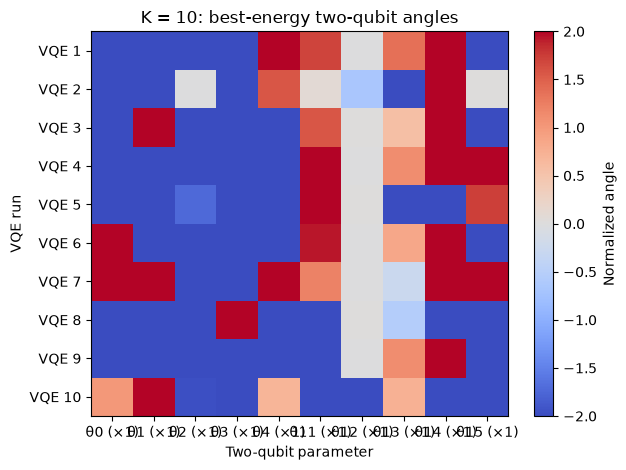

In [4]:
def phase_aware_initial_point(configuration, seed):
    """Return a seeded, deliberately displaced start for the N=3, F=2 model."""

    ansatz = configuration["ansatz"]
    K = float(configuration["hamiltonian"]["k"][0])
    qubits = ansatz["N"] * ansatz["F"]
    xy_parameters = qubits - 1
    if xy_parameters != 5:
        raise ValueError("This initializer is defined for the N=3, F=2 model.")
    if np.isclose(K, -14.0):
        xy_center = 0.25
    elif np.isclose(K, 0.0):
        xy_center = pi / 2
    elif np.isclose(K, 10.0):
        xy_center = pi - 0.25
    else:
        raise ValueError(f"No phase-aware initial point is defined for K={K}.")

    parameters_per_rep = xy_parameters + qubits
    point = np.zeros(ansatz["reps"] * parameters_per_rep)
    for rep in range(ansatz["reps"]):
        start = rep * parameters_per_rep
        point[start : start + xy_parameters] = xy_center
    point += np.random.default_rng(seed).normal(0.0, 0.10, size=point.size)
    return np.clip(point, -pi, pi)


PHASES = {
    "K = -14": {"N": N, "F": F, "m": [0.0] * F, "x": X, "k": [-14.0, 0.0]},
    "K = 0": {"N": N, "F": F, "m": [0.0] * F, "x": X, "k": [0.0, 0.0]},
    "K = 10": {"N": N, "F": F, "m": [0.0] * F, "x": X, "k": [10.0, 0.0]},
}

exact_energies = {}
exact_entropies = {}
results_by_phase = {}
phase_groups = {}
for phase_index, (phase, hamiltonian) in enumerate(PHASES.items()):
    experiment = vqe.Experiment(model, hamiltonian=hamiltonian, ansatz=ANSATZ)
    exact_result = experiment.exact(
        return_eigenvector=True, particle_number=N * F // 2
    )
    exact_energies[phase] = exact_result
    exact_entropies[phase] = vqe.entropy(exact_result.eigenvector)

    print(f"Exact ground state energy for {phase}: {exact_result.energy:.8f}")
    print(f"Half-chain entanglement entropy for {phase}: {exact_entropies[phase]:.8f} bits")
    print()

    results = vqe.run_grid(
        model,
        hamiltonian=hamiltonian,
        ansatz=ANSATZ,
        repeats=10,
        seed=24680 + 10_000 * phase_index,
        optimizer="lbfgsb",
        maxiter=800,
        optimizer_bounds=(-pi, pi),
        initial_point_factory=phase_aware_initial_point,
    )
    assert not results.failures, results.failures
    results_by_phase[phase] = results
    phase_groups[phase] = [(phase, results.runs)]

    vqe.plot_convergence(results.runs, exact=exact_result)
    plt.title(f"{phase}: convergence")
    plt.show()

    vqe.plot_entropy(results.runs, exact=exact_entropies[phase])
    plt.title(f"{phase}: entanglement entropy")
    plt.show()

    vqe.plot_parameters(results.runs, heatmap=True)
    plt.title(f"{phase}: best-energy two-qubit angles")
    plt.show()


## Cross-phase gate-angle comparison

The following plots retain every run and compare the same two-qubit ansatz parameters across all three phases.


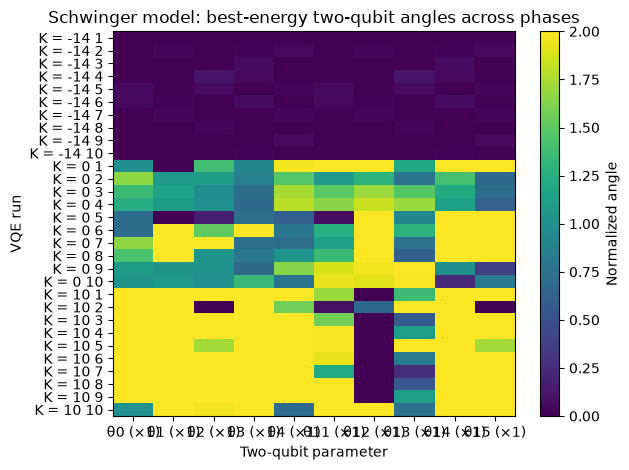

K = -14: best energy error = 0.00000000
K = 0: best energy error = 0.00599929
K = 10: best energy error = 0.00000000


In [7]:
groups = [(phase, results.runs) for phase, results in results_by_phase.items()]

vqe.plot_parameters(groups, heatmap=True, absolute=True)
plt.title("Schwinger model: best-energy two-qubit angles across phases")
plt.show()

for phase, results in results_by_phase.items():
    best_error = min(run.energy for run in results.runs) - exact_energies[phase].energy
    print(f"{phase}: best energy error = {best_error:.8f}")
